# Patch test-set evaluation & visualization

Load a trained patch model (`runs/patches/model.pt`), run inference on one **test** patch,
and plot field comparison (same layout as §4a in `04_results_visualization.ipynb`).

**Prerequisites**
- `python -m experiments.run_patches ...` finished (writes `model.pt` + `train_config.json`)
- `simulation/make_train_data.py` output with `test/` sub-folder

In [1]:
import sys, os, json, warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter
from scipy.stats import pearsonr
import torch

try:
    PROJECT = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    PROJECT = os.path.abspath('..')   # cwd = notebooks/

RUNS_DIR = os.path.join(PROJECT, 'runs')
sys.path.insert(0, PROJECT)

from data.loader import load_snapshot
from data.patch_loader import (
    load_patch, list_patch_dirs, load_manifest, build_graph_from_patch,
)
from data.preprocessing import compute_feature_stats
from models.checkpoint import (
    load_laepinn_checkpoint, muv_bin_edges_from_n_hod, infer_hparams_from_state_dict,
)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
C = dict(pred='#E05A4C', true='#3B7DD8', obs='#E8A838')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


In [12]:
# ── paths (edit these) ────────────────────────────────────────────
PATCH_DIR = "/Users/zihao/study/astrophysics/JWST/COSMOS-3D/shuffled_clustering/simulation/patches_z7.14"
RUN_DIR   = "/Users/zihao/study/astrophysics/JWST/COSMOS-3D/shuffled_clustering/run/patches"

# test patch folder name under PATCH_DIR/test/  (or None → first test patch)
TEST_PATCH_ID = '001335'          # e.g. '001331'
MUV_CUT_DEFAULT = -19.0       # default.yaml; overridden by train_config / checkpoint

cfg_path = os.path.join(RUN_DIR, 'train_config.json')
ckpt_path = os.path.join(RUN_DIR, 'model.pt')
train_cfg = None
if os.path.exists(cfg_path):
    with open(cfg_path) as f:
        train_cfg = json.load(f)
    print('Loaded train_config.json')

if train_cfg is not None:
    feat_stats = {k: tuple(v) for k, v in train_cfg['feature_stats'].items()}
    cfg = dict(train_cfg)
    MUV_CUT = float(cfg.get('muv_cut', MUV_CUT_DEFAULT))
else:
    MUV_CUT = MUV_CUT_DEFAULT
    print('train_config.json not found — inferring model hparams from checkpoint')
    print('  (recomputing feature_stats from train patches; ideally re-save train_config.json)')
    from data.patch_loader import load_patches
    feat_stats = compute_feature_stats(load_patches(PATCH_DIR, 'train'))
    sd = torch.load(ckpt_path, map_location='cpu')
    inferred = infer_hparams_from_state_dict(sd)
    cfg = {
        'excursion': inferred['excursion_type'],
        'n_hod_bins': inferred['n_hod_bins'],
        'muv_bin_edges': muv_bin_edges_from_n_hod(inferred['n_hod_bins']),
        'unresolved': 'linear',
        'profile_source': 'observed_acf',
        'dv_max': 1000.0,
        'n_lae_mass_bins': 4,
        'k_neighbors': 16,
        'r_link': 15.0,
        'sim_root': os.path.join(PROJECT, '..', 'simulation'),
    }
    manifest = load_manifest(PATCH_DIR)
    cfg['patch_grid'] = int(manifest.get('patch_grid', inferred.get('grid_size', 64)))
    cfg['patch_box_mpc'] = float(manifest.get('patch_box_mpc', 40))
    MUV_CUT = float(cfg['muv_bin_edges'][0])
    print(f"  inferred: excursion={cfg['excursion']}  n_hod_bins={cfg['n_hod_bins']}  muv_cut={MUV_CUT}")

G        = int(cfg['patch_grid'])
BOX      = float(cfg['patch_box_mpc'])
muv_bins = cfg.get('muv_bin_edges', list(np.arange(MUV_CUT, -15 + 1e-6, 0.5)))

test_dirs = list_patch_dirs(PATCH_DIR, 'test')
if TEST_PATCH_ID is not None:
    patch_dir = os.path.join(PATCH_DIR, 'test', TEST_PATCH_ID)
else:
    patch_dir = test_dirs[0]
print(f'Test patch: {patch_dir}')

train_config.json not found — inferring model hparams from checkpoint
  (recomputing feature_stats from train patches; ideally re-save train_config.json)
  inferred: excursion=bubble  n_hod_bins=9  muv_cut=-19.0
Test patch: /Users/zihao/study/astrophysics/JWST/COSMOS-3D/shuffled_clustering/simulation/patches_z7.14/test/001335


In [13]:
# ── load model + build graph for the test patch ───────────────────
model, cfg = load_laepinn_checkpoint(
    os.path.join(RUN_DIR, 'model.pt'),
    train_config=train_cfg,
    map_location=DEVICE,
)
muv_bins = cfg.get('muv_bin_edges', muv_bin_edges_from_n_hod(int(cfg['n_hod_bins'])))
MUV_CUT = float(cfg.get('muv_cut', muv_bins[0]))
G = int(cfg.get('patch_grid', G))
BOX = float(cfg.get('patch_box_mpc', BOX))
print(f"Model: excursion={cfg.get('excursion')}  n_hod_bins={cfg['n_hod_bins']}  muv_cut={MUV_CUT}")

snap_full = None
if cfg.get('unresolved') == 'conditional':
    snap_full = load_snapshot(cfg.get('sim_root', '../simulation'),
                                float(load_manifest(PATCH_DIR).get('redshift', 7.14)))

patch = load_patch(patch_dir)
graph = build_graph_from_patch(
    patch, feat_stats,
    muv_cut=MUV_CUT,
    muv_bin_edges=muv_bins,
    muv_det=MUV_CUT,
    unresolved=cfg.get('unresolved', 'linear'),
    snap_full=snap_full,
    profile_source=cfg.get('profile_source', 'observed_acf'),
    dv_max_kms=float(cfg.get('dv_max', 1000)),
    n_lae_mass_bins=int(cfg.get('n_lae_mass_bins', 4)),
    k=int(cfg.get('k_neighbors', 16)),
    r_max=float(cfg.get('r_link', 15)),
    device=DEVICE,
)
assert graph is not None, 'No LAEs in patch after MUV cut'

with torch.no_grad():
    g = graph.to(DEVICE)
    out = model(
        g, hod_basis=g.hod_basis, return_intermediates=False,
        density_grid=getattr(g, 'density_grid', None),
    )

x_pred = out['x_hii_pred'].cpu().numpy()
x_true = g.xbox_true.squeeze().cpu().numpy()
print(f'Patch {patch.patch_id}  origin={patch.origin_mpc}  N_LAE={graph.num_nodes}')
print(f'xi_true={x_true.mean():.3f}  xi_pred={x_pred.mean():.3f}')

Model: excursion=bubble  n_hod_bins=9  muv_cut=-19.0
Patch 1335  origin=(120.0, 0.0, 32.0)  N_LAE=127
xi_true=0.307  xi_pred=0.310


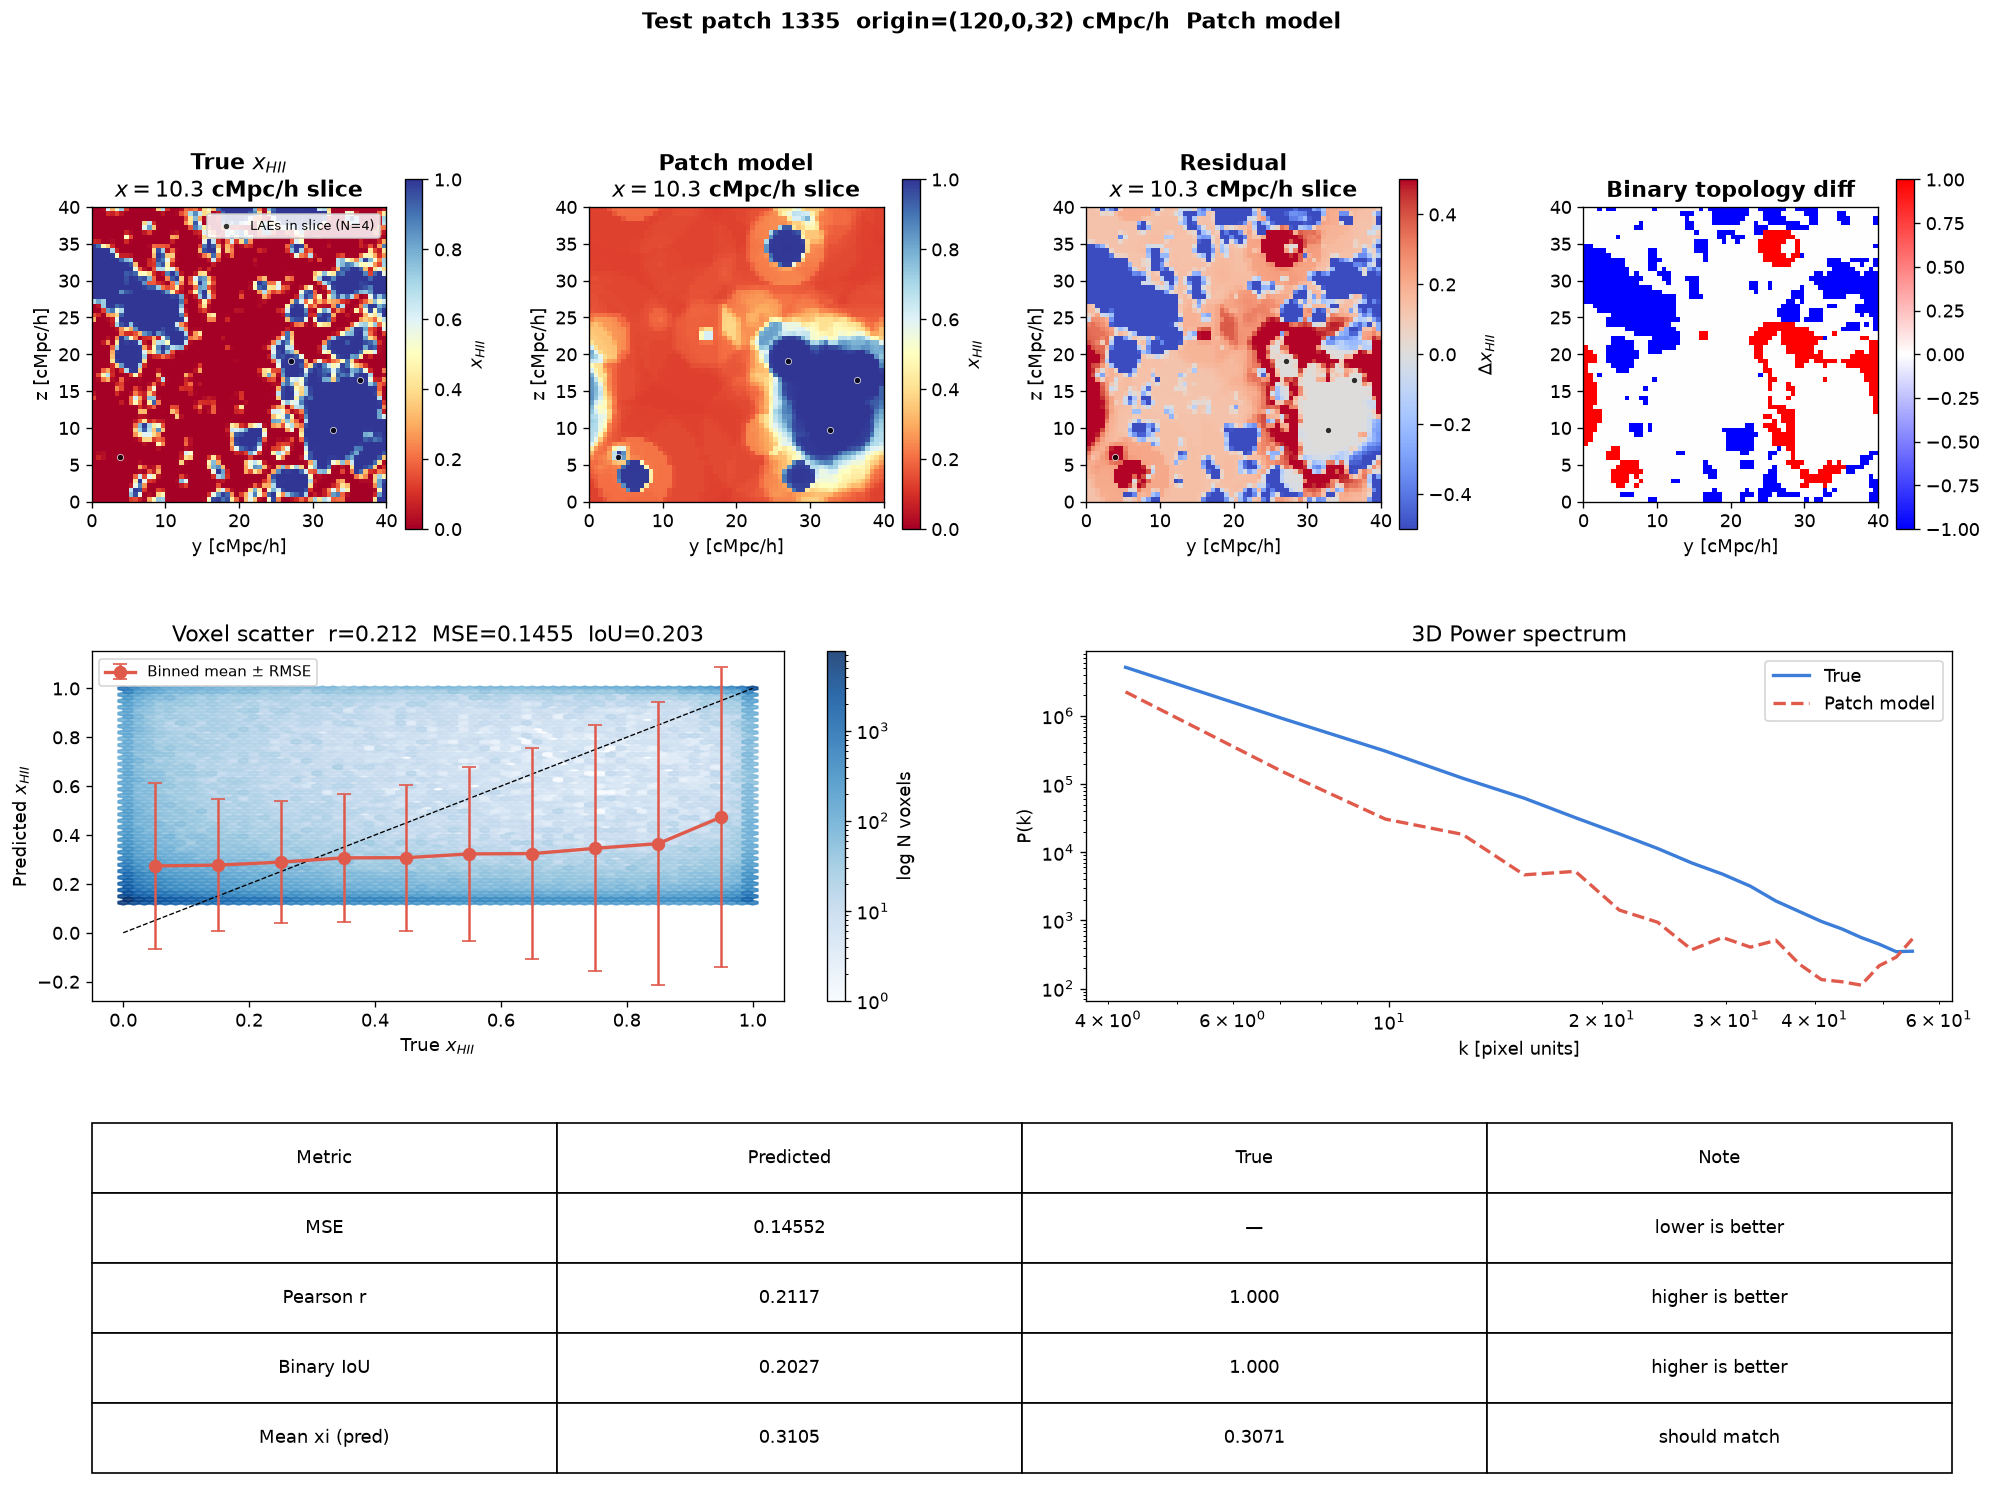

In [15]:
# ── field comparison figure (§4a layout, patch coordinates) ───────
label_str = 'Patch model'
sl = G // 4
box_fc = BOX
x_sl = (sl + 0.5) * box_fc / G          # slice plane along axis 0
dz = box_fc / G

cat = dict(np.load(os.path.join(patch_dir, 'catalog.npz')))
muv = cat['muv']
pos_lae = cat['pos'][muv < MUV_CUT]
in_slice = np.abs(pos_lae[:, 0] - x_sl) < dz*2
pos_sl = pos_lae[in_slice]
n_sl = int(in_slice.sum())

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.35, wspace=0.35)
ext = [0, box_fc, 0, box_fc]

# Row 1: slices (axis-0 fixed → plot y–z)
kw = dict(origin='lower', extent=ext, vmin=0, vmax=1, cmap='RdYlBu')
for row_ax, field, title in [
    (fig.add_subplot(gs[0, 0]), x_true, 'True $x_{HII}$'),
    (fig.add_subplot(gs[0, 1]), x_pred, label_str),
    (fig.add_subplot(gs[0, 2]), x_pred - x_true, 'Residual'),
]:
    if 'Residual' in title:
        im = row_ax.imshow(field[sl, :, :].T, origin='lower', extent=ext,
                           cmap='coolwarm', vmin=-0.5, vmax=0.5)
        plt.colorbar(im, ax=row_ax, label='Δ$x_{HII}$')
    else:
        im = row_ax.imshow(field[sl, :, :].T, **kw)
        plt.colorbar(im, ax=row_ax, label='$x_{HII}$')
    if n_sl:
        lbl = f'LAEs in slice (N={n_sl})' if title.startswith('True') else None
        row_ax.scatter(pos_sl[:, 1], pos_sl[:, 2], s=14, c='k', alpha=0.8,
                       linewidths=0.5, edgecolors='white', zorder=5, label=lbl)
    row_ax.set_title(f'{title}\n$x={x_sl:.1f}$ cMpc/h slice', fontweight='bold')
    row_ax.set_xlabel('y [cMpc/h]')
    if title.startswith('True') and n_sl:
        row_ax.legend(loc='upper right', fontsize=8, framealpha=0.85)
    row_ax.set_ylabel('z [cMpc/h]')

ax_bin = fig.add_subplot(gs[0, 3])
diff_bin = (x_pred > 0.5).astype(float) - (x_true > 0.5).astype(float)
im = ax_bin.imshow(diff_bin[sl, :, :].T, origin='lower', extent=ext, cmap='bwr', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax_bin)
ax_bin.set_title('Binary topology diff', fontweight='bold')
ax_bin.set_xlabel('y [cMpc/h]')

# Row 2: voxel scatter + power spectrum
ax_sc = fig.add_subplot(gs[1, :2])
xt = gaussian_filter(x_true, sigma=1).flatten()
xp = gaussian_filter(x_pred, sigma=1).flatten()
hb = ax_sc.hexbin(xt, xp, gridsize=60, cmap='Blues', bins='log', alpha=0.85)
ax_sc.plot([0, 1], [0, 1], 'k--', lw=0.8, zorder=5)

n_bins_sc = 10
edges_sc = np.linspace(0, 1, n_bins_sc + 1)
xc_sc, ym_sc, err_sc = [], [], []
for i, (lo, hi) in enumerate(zip(edges_sc[:-1], edges_sc[1:])):
    m = (xt >= lo) & (xt < hi) if i < n_bins_sc - 1 else (xt >= lo) & (xt <= hi)
    if not m.any():
        continue
    resid = xp[m] - xt[m]
    xc_sc.append(0.5 * (lo + hi))
    ym_sc.append(float(xp[m].mean()))
    err_sc.append(float(np.sqrt(np.mean(resid ** 2))))
ax_sc.errorbar(xc_sc, ym_sc, yerr=err_sc, fmt='o-', color=C['pred'], lw=2, ms=7,
               capsize=4, elinewidth=1.5, zorder=10, label=r'Binned mean $\pm$ RMSE')

r_corr, _ = pearsonr(xt, xp)
mse_val = float(np.mean((xp - xt) ** 2))
bp, bt = xp > 0.5, xt > 0.5
iou = (bp & bt).sum() / ((bp | bt).sum() + 1e-8)
ax_sc.set_xlabel('True $x_{HII}$')
ax_sc.set_ylabel('Predicted $x_{HII}$')
ax_sc.set_title(f'Voxel scatter  r={r_corr:.3f}  MSE={mse_val:.4f}  IoU={iou:.3f}')
ax_sc.legend(loc='upper left', fontsize=9)
plt.colorbar(hb, ax=ax_sc, label='log N voxels')

ax_ps = fig.add_subplot(gs[1, 2:])

def compute_ps_1d(field, G=G, n_bins=20):
    fk = np.fft.rfftn(field)
    pk = np.abs(fk) ** 2
    kx = np.fft.fftfreq(G) * G
    ky = np.fft.fftfreq(G) * G
    kz = np.fft.rfftfreq(G) * G
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
    kmag = np.sqrt(KX ** 2 + KY ** 2 + KZ ** 2).flatten()
    pk_f = pk.flatten()
    bins = np.linspace(0, kmag.max() + 1, n_bins + 1)
    rc = 0.5 * (bins[:-1] + bins[1:])
    ps_vals = np.zeros(n_bins)
    for i in range(n_bins):
        m = (kmag >= bins[i]) & (kmag < bins[i + 1])
        if m.any():
            ps_vals[i] = pk_f[m].mean()
    return rc, ps_vals

kc, ps_true = compute_ps_1d(x_true)
kc, ps_pred = compute_ps_1d(x_pred)
ax_ps.loglog(kc[1:], ps_true[1:], color=C['true'], lw=2, label='True')
ax_ps.loglog(kc[1:], ps_pred[1:], color=C['pred'], lw=2, ls='--', label=label_str)
ax_ps.set_xlabel('k [pixel units]')
ax_ps.set_ylabel('P(k)')
ax_ps.set_title('3D Power spectrum')
ax_ps.legend()

# Row 3: metrics table
ax_tab = fig.add_subplot(gs[2, :])
ax_tab.axis('off')
table_data = [
    ['MSE', f'{mse_val:.5f}', '—', 'lower is better'],
    ['Pearson r', f'{r_corr:.4f}', '1.000', 'higher is better'],
    ['Binary IoU', f'{iou:.4f}', '1.000', 'higher is better'],
    ['Mean xi (pred)', f'{xp.mean():.4f}', f'{xt.mean():.4f}', 'should match'],
]
ax_tab.table(cellText=table_data,
             colLabels=['Metric', 'Predicted', 'True', 'Note'],
             cellLoc='center', loc='center', bbox=[0, 0, 1, 1])

origin = patch.origin_mpc
fig.suptitle(
    f'Test patch {patch.patch_id}  origin=({origin[0]:.0f},{origin[1]:.0f},{origin[2]:.0f}) cMpc/h  {label_str}',
    fontweight='bold', fontsize=13,
)
plt.show()

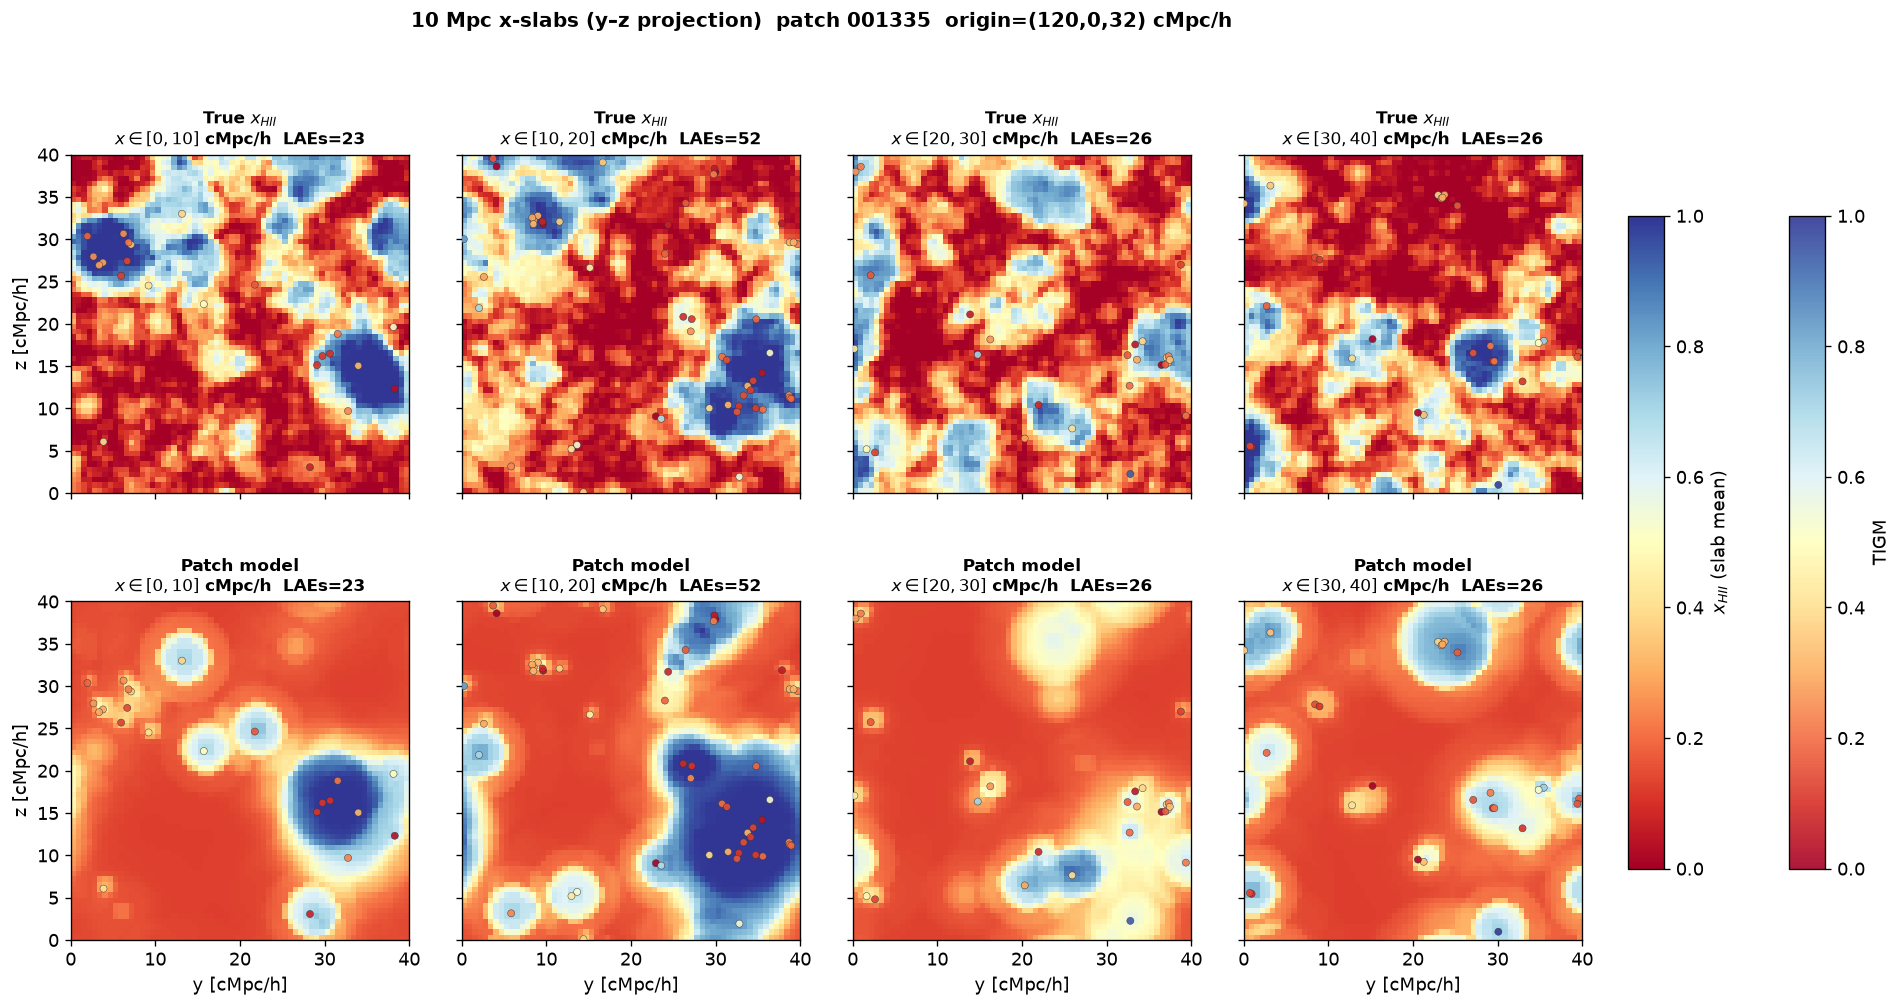

In [18]:
# ── x-slabs: 10 Mpc average + LAEs in each slab (2 rows × 4 cols) ──
SLAB_W = 10.0   # cMpc/h slab width along x
n_cols = int(round(BOX / SLAB_W))
x_vox = (np.arange(G) + 0.5) * BOX / G
ext = [0, BOX, 0, BOX]
kw_slab = dict(origin='lower', extent=ext, vmin=0, vmax=1, cmap='RdYlBu')

cat = dict(np.load(os.path.join(patch_dir, 'catalog.npz')))
lae_m = cat['muv'] < MUV_CUT
pos_lae = cat['pos'][lae_m]
tigm_lae = cat['tigm'][lae_m]

fig2, axes = plt.subplots(2, n_cols, figsize=(4.2 * n_cols, 8.5), sharex=True, sharey=True)
if n_cols == 1:
    axes = np.array(axes).reshape(2, 1)
sc_tigm = None

for col in range(n_cols):
    x_lo = col * SLAB_W
    x_hi = (col + 1) * SLAB_W
    if col < n_cols - 1:
        xm = (x_vox >= x_lo) & (x_vox < x_hi)
        gal_m = (pos_lae[:, 0] >= x_lo) & (pos_lae[:, 0] < x_hi)
    else:
        xm = (x_vox >= x_lo) & (x_vox <= x_hi)
        gal_m = (pos_lae[:, 0] >= x_lo) & (pos_lae[:, 0] <= x_hi)

    img_true = x_true[xm].mean(axis=0)
    img_pred = x_pred[xm].mean(axis=0)
    pos_slab = pos_lae[gal_m]
    tigm_slab = tigm_lae[gal_m]
    n_gal = int(gal_m.sum())

    for row, (img, row_lbl) in enumerate([(img_true, 'True $x_{HII}$'), (img_pred, label_str)]):
        ax = axes[row, col]
        im = ax.imshow(img.T, **kw_slab)
        if n_gal:
            sc_tigm = ax.scatter(
                pos_slab[:, 1], pos_slab[:, 2], s=18, c=tigm_slab,
                cmap='RdYlBu', vmin=0, vmax=1, alpha=0.9,
                linewidths=0.3, edgecolors='0.2', zorder=5,
            )
        ax.set_title(
            f'{row_lbl}\n$x\\in[{x_lo:.0f},{x_hi:.0f}]$ cMpc/h  LAEs={n_gal}',
            fontsize=10, fontweight='bold',
        )
        if col == 0:
            ax.set_ylabel('z [cMpc/h]')
        if row == 1:
            ax.set_xlabel('y [cMpc/h]')

fig2.subplots_adjust(hspace=0.32, wspace=0.12, right=0.88)
cax = fig2.add_axes([0.90, 0.18, 0.018, 0.64])
fig2.colorbar(im, cax=cax, label='$x_{HII}$ (slab mean)')
if sc_tigm is not None:
    cax_t = fig2.add_axes([0.98, 0.18, 0.018, 0.64])
    fig2.colorbar(sc_tigm, cax=cax_t, label='TIGM')
origin = patch.origin_mpc
fig2.suptitle(
    f'10 Mpc x-slabs (y–z projection)  patch {patch.patch_id:06d}  '
    f'origin=({origin[0]:.0f},{origin[1]:.0f},{origin[2]:.0f}) cMpc/h',
    fontweight='bold', fontsize=12, y=1.02,
)
plt.show()

## Optional: loop over all test patches (aggregate metrics)

In [10]:
from data.patch_loader import build_graph_list_from_patches

graph_kw = dict(
    muv_cut=MUV_CUT, muv_bin_edges=muv_bins, muv_det=MUV_CUT,
    unresolved=cfg.get('unresolved', 'linear'), snap_full=snap_full,
    profile_source=cfg.get('profile_source', 'observed_acf'),
    dv_max_kms=float(cfg.get('dv_max', 1000)),
    n_lae_mass_bins=int(cfg.get('n_lae_mass_bins', 4)),
    k=int(cfg.get('k_neighbors', 16)), r_max=float(cfg.get('r_link', 15)),
    device=DEVICE, verbose=False,
)
test_graphs, _ = build_graph_list_from_patches(PATCH_DIR, 'test', stats=feat_stats, **graph_kw)

mses, ious, corrs = [], [], []
model.eval()
with torch.no_grad():
    for g in test_graphs:
        g = g.to(DEVICE)
        out = model(g, hod_basis=g.hod_basis,
                    density_grid=getattr(g, 'density_grid', None))
        xp = out['x_hii_pred'].cpu().numpy().ravel()
        xt = g.xbox_true.squeeze().cpu().numpy().ravel()
        mses.append(np.mean((xp - xt) ** 2))
        bp, bt = xp > 0.5, xt > 0.5
        ious.append((bp & bt).sum() / ((bp | bt).sum() + 1e-8))
        corrs.append(np.corrcoef(xp, xt)[0, 1])

print(f'Test patches: {len(test_graphs)}')
print(f'  MSE     mean={np.mean(mses):.5f}  std={np.std(mses):.5f}')
print(f'  IoU     mean={np.mean(ious):.4f}  std={np.std(ious):.4f}')
print(f'  Pearson mean={np.mean(corrs):.4f}  std={np.std(corrs):.4f}')

Test patches: 256
  MSE     mean=0.23206  std=0.03305
  IoU     mean=0.2487  std=0.1136
  Pearson mean=0.1547  std=0.0891
